In [1]:
import pandas as pd
import numpy as np

In [94]:
df=pd.read_excel("Delinquency_prediction_dataset.xlsx")

In [3]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [112]:
df.tail()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Loan_Balance_missing,Income_missing
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,...,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late,0,0
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,...,Student,Houston,On-time,On-time,Late,Late,Late,Missed,0,0
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,...,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed,0,0
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,...,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed,0,0
499,CUST0500,25,40945.0,442.0,0.911370,1,0,36968.0,0.370422,Self-employed,...,Business,Houston,Missed,Late,Late,On-time,Late,On-time,0,0


In [116]:
df.sample(5)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Loan_Balance_missing,Income_missing
244,CUST0245,34,193677.0,380.0,0.328232,2,0,83604.0,0.293594,Unemployed,...,Gold,Los Angeles,Late,On-time,Missed,On-time,Missed,Missed,0,0
463,CUST0464,42,107658.0,837.0,0.621728,5,0,45776.0,0.267268,retired,...,Standard,Los Angeles,On-time,Missed,On-time,Late,Late,Late,0,1
23,CUST0024,47,108468.0,538.0,0.816191,2,1,45776.0,0.317053,retired,...,Gold,Phoenix,Late,Late,Late,On-time,Late,Late,1,0
432,CUST0433,59,31364.0,739.0,0.700700,2,0,24851.0,0.257964,EMP,...,Business,Houston,On-time,Late,On-time,Missed,On-time,Missed,0,0
460,CUST0461,43,146800.0,459.0,0.671418,4,1,17913.0,0.165185,Employed,...,Standard,Los Angeles,Missed,Missed,On-time,On-time,Late,Missed,0,0


In [117]:
df.dtypes

,0
Customer_ID,object
Age,int64
Income,float64
Credit_Score,float64
Credit_Utilization,float64
Missed_Payments,int64
Delinquent_Account,int64
Loan_Balance,float64
Debt_to_Income_Ratio,float64
Employment_Status,object


In [96]:
df['Income'].isnull().sum()

np.int64(39)

In [97]:
Mean=df.Income.mean()

In [17]:
round(Mean , 2)

np.float64(108379.89)

In [9]:
df.Income.median()

107658.0

In [20]:
df.Income.skew()  ## Perfectly skewed

np.float64(0.0460865090566657)

# Treatment of missing and duplicate values

In [105]:
df['Income_missing'] = df['Income'].isna().astype(int)
df['Income'] = df['Income'].fillna(df['Income'].median())

In [98]:
df

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed


In [21]:
df.Loan_Balance.skew()  ## highly skewd

np.float64(0.1051966422322644)

In [99]:
df['Loan_Balance_missing'] = df['Loan_Balance'].isnull().astype(int)
df['Loan_Balance'] = df['Loan_Balance'].fillna(df['Loan_Balance'].median())

In [100]:
df

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Loan_Balance_missing
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late,0
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time,0
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late,0
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late,0
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late,0
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed,0
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed,0
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed,0


In [102]:
df['Credit_Score'] = df['Credit_Score'].fillna(
    df['Credit_Score'].median()
)

In [103]:
df

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Loan_Balance_missing
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late,0
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time,0
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late,0
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late,0
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late,0
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed,0
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed,0
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed,0


In [106]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [32]:
df.Employment_Status.unique()

array(['EMP', 'Self-employed', 'Unemployed', 'employed', 'Employed',
       'retired'], dtype=object)

In [48]:
df.Employment_Status.replace(['EMP','employed','Employed'],'Employed' , inplace=True)

#EDA

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

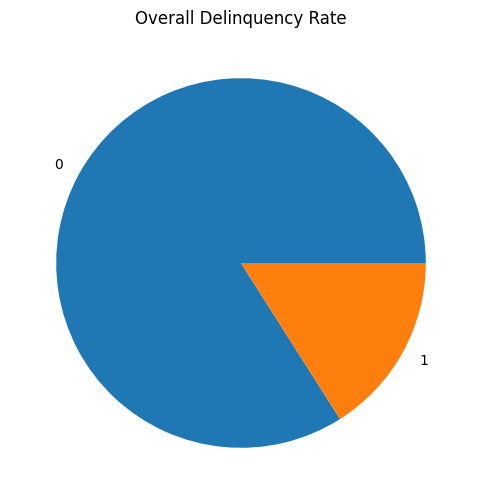

In [37]:
## Delinquency Pattern
plt.figure(figsize=(6,6))
df['Delinquent_Account'].value_counts().plot(kind='pie') ##, autopct='%1.1f%%', startangle=90)
plt.title("Overall Delinquency Rate")
plt.ylabel("")
plt.show()


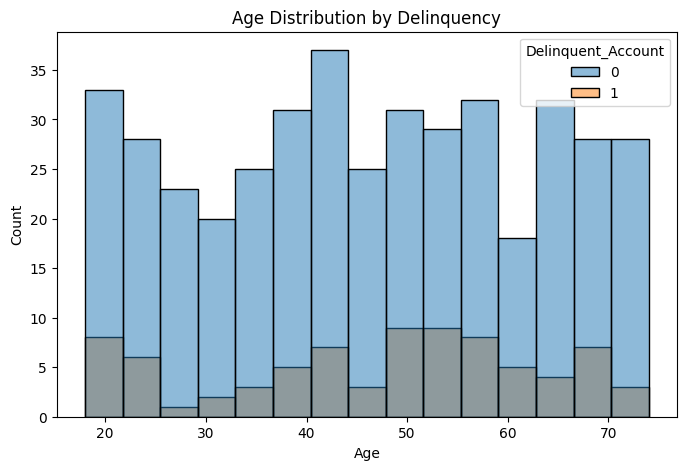

In [44]:
## Age Group Vs Delinquency
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Delinquent_Account', multiple='layer',bins=15, kde=False)
plt.title("Age Distribution by Delinquency")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_1603/3381249041.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Pink'` for the same effect.

  sns.countplot(x='Employment_Status', hue='Delinquent_Account', data=df , color="Pink")


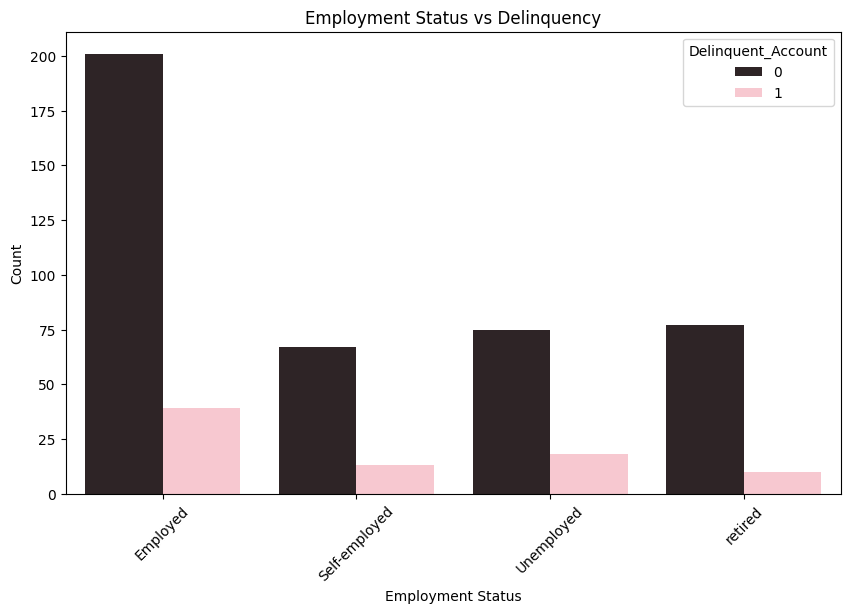

In [63]:
## Employement Status vs delinquency
plt.figure(figsize=(10,6))
sns.countplot(x='Employment_Status', hue='Delinquent_Account', data=df , color="Pink")
plt.title("Employment Status vs Delinquency")
plt.xlabel("Employment Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_1603/85606478.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Green'` for the same effect.

  sns.countplot(x='Credit_Card_Type', hue='Delinquent_Account', data=df , color ="Green")


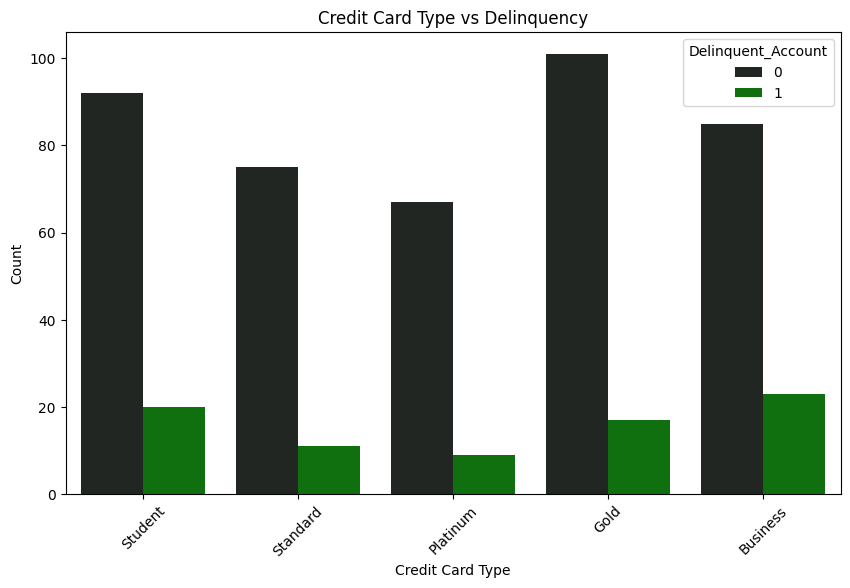

In [67]:
## Credit Card Type vs Delinquency
plt.figure(figsize=(10,6))
sns.countplot(x='Credit_Card_Type', hue='Delinquent_Account', data=df , color ="Green")
plt.title("Credit Card Type vs Delinquency")
plt.xlabel("Credit Card Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


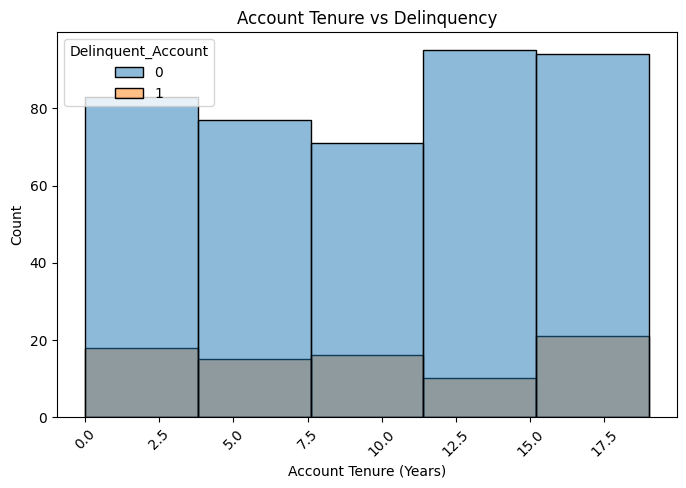

In [83]:
## Account Tenusre VS delinquency
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Account_Tenure', hue='Delinquent_Account' ,multiple="layer",color="Yellow", bins=5, kde=False)
plt.title("Account Tenure vs Delinquency")
plt.xlabel("Account Tenure (Years)")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


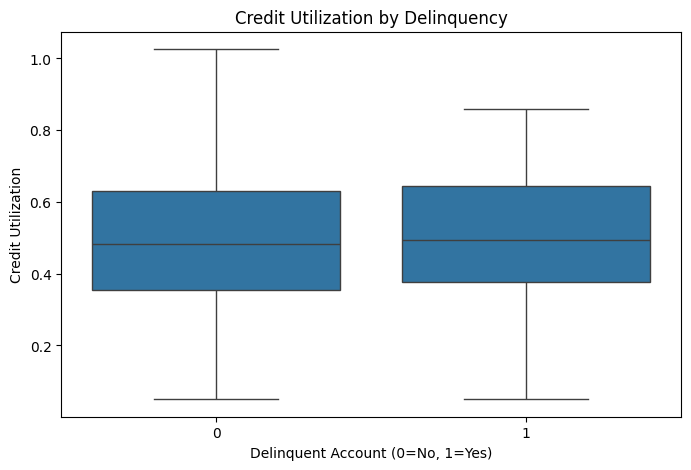

In [85]:
## credit utilization vs delinquency
plt.figure(figsize=(8,5))
sns.boxplot(x='Delinquent_Account', y='Credit_Utilization', data=df)
plt.title("Credit Utilization by Delinquency")
plt.xlabel("Delinquent Account (0=No, 1=Yes)")
plt.ylabel("Credit Utilization")
plt.show()


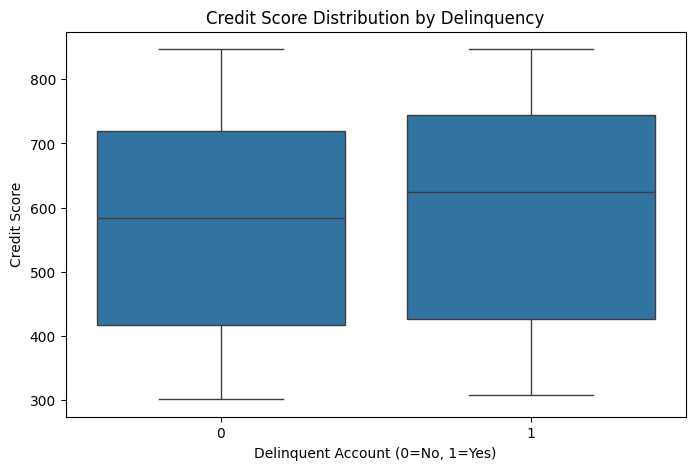

In [107]:
## Credit score vs delinquency
plt.figure(figsize=(8,5))
sns.boxplot(x='Delinquent_Account', y='Credit_Score', data=df)
plt.title("Credit Score Distribution by Delinquency")
plt.xlabel("Delinquent Account (0=No, 1=Yes)")
plt.ylabel("Credit Score")
plt.show()


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                500 non-null    float64
 3   Credit_Score          0 non-null      float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          0 non-null      float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [110]:
df.Credit_Score.count()

np.int64(500)

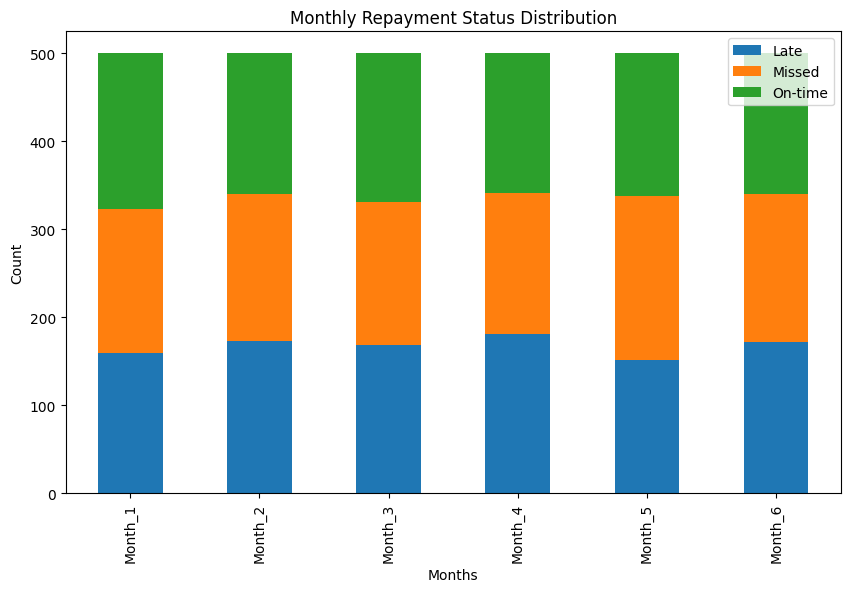

In [111]:
## Monthly Payment History
monthly_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']
status_counts = df[monthly_cols].apply(pd.Series.value_counts).fillna(0)

status_counts.T.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Monthly Repayment Status Distribution")
plt.xlabel("Months")
plt.ylabel("Count")
plt.show()


## Insights
Age: Customers aged 46–59 show the highest delinquency (22.4%).

Employment Status: Unemployed (19.4%) and employed (18.3%) both carry risk; retired customers are safer (11.5%).

Credit Card Type: Business card holders (21.3%) are almost twice as risky as Platinum (11.8%).

Account Tenure: Risk peaks at 5–10 years (19.7%), but drops sharply at 10–15 years (9.1%).